In [20]:
import glob
import os
import numpy as np
import pandas as pd

# 그룹별 피처 맵핑 정의 (참조용)
META_FEATURE_MAPPING = {
    "2017": {
        "Volume": [
            "Total Fwd Packets",
            "Total Backward Packets",
            "Flow Packets/s",
            "Fwd Packets/s",
            "Bwd Packets/s",
            "Flow Bytes/s",
        ],
        "Size_Payload": [
            "Min Packet Length",
            "Max Packet Length",
            "Packet Length Mean",
            "Packet Length Std",
            "Packet Length Variance",
            "Average Packet Size",
            "Fwd Packet Length Max",
            "Bwd Packet Length Max",
            "Total Length of Fwd Packets",
            "Total Length of Bwd Packets",
        ],
        "Topology": [
            "Destination Port",
            "Down/Up Ratio",
            "Subflow Fwd Packets",
            "Subflow Bwd Packets",
            "Init_Win_bytes_forward",
            "Init_Win_bytes_backward",
        ],
        "Control_State": [
            "SYN Flag Count",
            "RST Flag Count",
            "ACK Flag Count",
            "FIN Flag Count",
            "Flow IAT Mean",
        ],
    },
    "2025": {
        "Volume": [
            "network_packets_all_count",
            "network_packets_dst_count",
            "network_packets_src_count",
            "log_messages_count",
            "network_interval-packets",
        ],
        "Size_Payload": [
            "network_packet-size_min",
            "network_packet-size_max",
            "network_packet-size_avg",
            "network_packet-size_std_deviation",
            "network_payload-length_avg",
            "network_ip-length_avg",
        ],
        "Topology": [
            "network_ports_all_count",
            "network_ports_dst_count",
            "network_ports_src_count",
            "network_ips_all_count",
            "network_ips_dst_count",
            "network_ips_src_count",
        ],
        "Control_State": [
            "network_tcp-flags-syn_count",
            "network_tcp-flags-rst_count",
            "network_tcp-flags-ack_count",
            "network_tcp-flags-fin_count",
            "network_ttl_avg",
            "network_window-size_avg",
        ],
    },
}

# Parquet 파일 경로 지정 (단일 파일 혹은 패턴)
path = "../data/processed_data/master_scored_dataset_Logged_z_cap5.parquet"
files = glob.glob(path)

if files:
    print(">> Parquet 파일 로딩 중...")
    df_master = pd.read_parquet(files[0])
    print(">> 로딩 완료!")

    target_scores = [
        "Risk_Score", 
        "Volume_Score", 
        "Size_Payload_Score",  # 띄어쓰기 -> 언더바 반영
        "Topology_Score", 
        "Control_State_Score"
    ]
    
    # 데이터프레임에 존재하는 컬럼만 필터링
    available_scores = [col for col in target_scores if col in df_master.columns]
    
    # Normal 그룹 필터링 (안전장치 포함)
    if "Normal" in df_master["Attack_Group"].values:
        df_normal = df_master[df_master["Attack_Group"] == "Normal"]
    else:
        df_normal = df_master[df_master["Attack_Group"].str.lower() == "normal"]

    # 연도별 및 점수별 통계량 산출
    normal_stats = (
        df_normal
        .groupby("Year")[available_scores]
        .agg(["mean", "std", "min", "max", "median"])
    )
    
    print("\n" + "="*50)
    print(" === [Normal 그룹 연도별 영역별 점수 통계 요약] ===")
    print("="*50)
    
    for score in available_scores:
        print(f"\n[지표: {score}]")
        print(normal_stats[score].to_string())
        print("-" * 40)
        
else:
    print(">> 지정된 경로에 Parquet 파일이 없습니다.")


>> Parquet 파일 로딩 중...
>> 로딩 완료!

 === [Normal 그룹 연도별 영역별 점수 통계 요약] ===

[지표: Risk_Score]
       mean    std    min    max  median
Year                                    
2017 1.0238 0.3161 0.5680 6.4163  0.9380
2025 1.2268 0.6015 0.4214 9.9824  1.1839
----------------------------------------

[지표: Volume_Score]
       mean    std    min    max  median
Year                                    
2017 0.1391 0.1219 0.0242 1.8793  0.1162
2025 0.2865 0.1764 0.0085 2.7259  0.2684
----------------------------------------

[지표: Size_Payload_Score]
       mean    std    min    max  median
Year                                    
2017 0.3222 0.1802 0.0753 2.4917  0.2786
2025 0.3704 0.2276 0.0294 2.3061  0.3134
----------------------------------------

[지표: Topology_Score]
       mean    std    min    max  median
Year                                    
2017 0.2949 0.1053 0.1119 1.8689  0.2291
2025 0.2903 0.2869 0.0908 3.0131  0.2386
----------------------------------------

[지표: Control_State_Sco

In [21]:

# 1. Normal 그룹만 추출하여 연도별 Risk_Score의 평균과 표준편차 계산
df_normal = df_master[df_master["Attack_Group"].str.lower() == "normal"]

normal_stats = df_normal.groupby("Year")["Risk_Score"].agg(
    Normal_Risk_Mean="mean",
    Normal_Risk_STD="std"
).reset_index()

print("\n=== [연도별 Normal Risk Score 통계] ===")
print(normal_stats)

# 2. 마스터 데이터프레임에 연도(Year)를 기준으로 Normal 통계치 병합(Merge)
df_master = pd.merge(df_master, normal_stats, on="Year", how="left")

# 3. 이탈도(Deviation) 계산
# 분모(표준편차)가 0이거나 NaN인 경우를 대비해 안전장치(.replace(0, np.nan)) 추가
df_master["Risk_Deviation"] = (
    df_master["Risk_Score"] - df_master["Normal_Risk_Mean"]
) / df_master["Normal_Risk_STD"].replace(0, np.nan)

# 4. 결과 확인 (공격 그룹별 Risk Deviation의 평균, 중앙값, 95%/99% 분위수 요약)
print("\n=== [공격 그룹별 Risk Deviation 상세 통계 비교] ===")
deviation_summary = (
    df_master.groupby(["Year", "Attack_Group"])["Risk_Deviation"]
    .agg(
        mean="mean",
        median="median",
        p95=lambda x: np.nanpercentile(x, 95), # 95% 분위수
        p99=lambda x: np.nanpercentile(x, 99), # 99% 분위수
        max="max",
        count="count"
    )
    .reset_index()
)

print(deviation_summary.to_string(index=False))



=== [연도별 Normal Risk Score 통계] ===
   Year  Normal_Risk_Mean  Normal_Risk_STD
0  2017            1.0238           0.3161
1  2025            1.2268           0.6015

=== [공격 그룹별 Risk Deviation 상세 통계 비교] ===
Year     Attack_Group    mean  median     p95     p99     max   count
2017      Brute Force  0.0851 -0.3069  1.9708  2.3613  4.9766   13835
2017       DoS / DDoS  2.1976  2.6771  4.0370  4.6655  8.5254  380688
2017       Heartbleed  7.3900  7.6345  7.7632  7.8119  7.8241      11
2017     Infiltration  1.5414  0.9929  4.9320  5.1401  5.2024      36
2017 Malware / Botnet -0.3634 -0.8368  1.5633  3.7596  5.2581    1966
2017           Normal  0.0000 -0.2715  2.0284  3.4821 17.0613 2273097
2017     Recon / Scan -0.3451 -0.3632  0.2043  1.2059  3.7449  158930
2017       Web Attack  0.4975  0.5769  0.5997  1.9786  2.5665    2180
2025      Brute Force  3.1215  3.1263  7.1042  9.3776 10.3790    6016
2025       DoS / DDoS  8.1417  8.8134 12.9219 15.6797 17.7286  114428
2025             MITM  

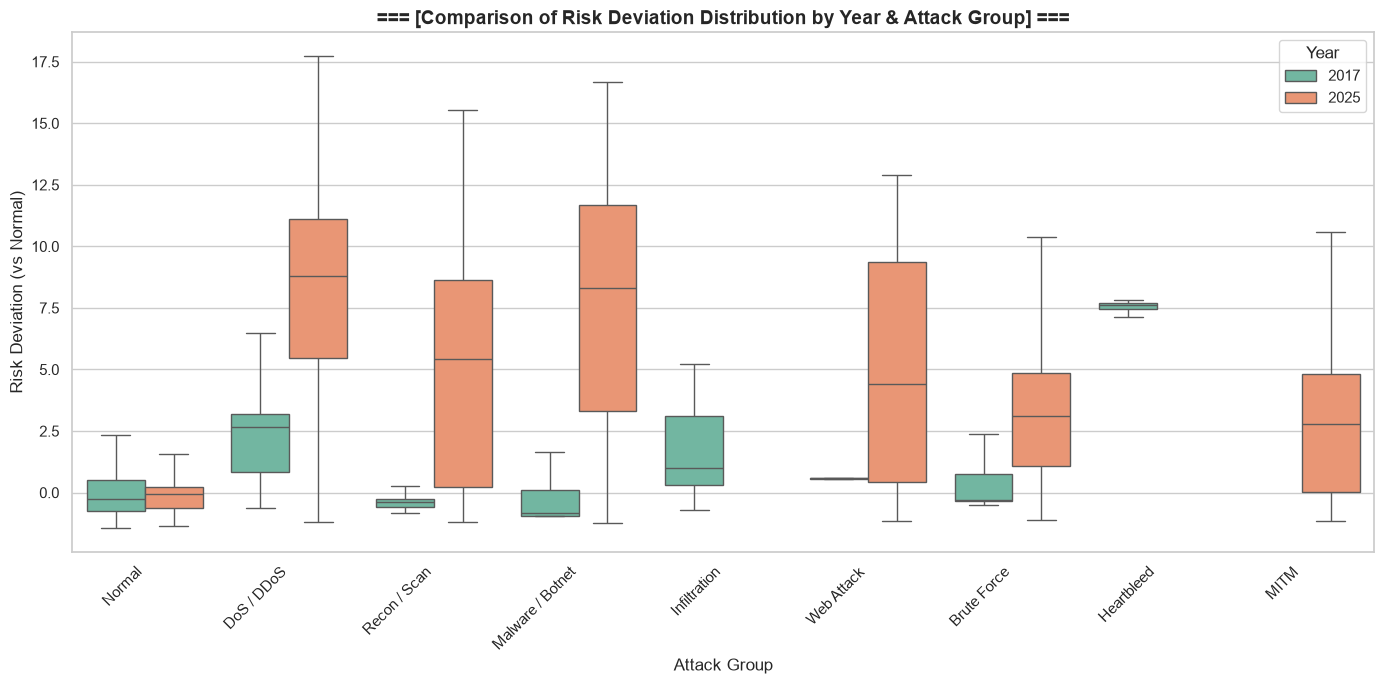

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Seaborn 박스플롯 그리기 (로그 스케일 또는 Y축 제한이 필요할 수 있으므로 hue나 연도별 분기 처리)
# 2017년과 2025년을 구분해서 보기 위해 연도(Year)를 기준으로 서브플롯을 나누거나 색상으로 구분합니다.
ax = sns.boxplot(
    data=df_master, 
    x="Attack_Group", 
    y="Risk_Deviation", 
    hue="Year",
    palette="Set2",
    showfliers=False  # 극단적인 이상치(Outlier) 점들이 너무 많아 그림이 깨지면 True -> False로 조정하세요
)

plt.title("=== [Comparison of Risk Deviation Distribution by Year & Attack Group] ===", fontsize=14, fontweight='bold')
plt.xlabel("Attack Group", fontsize=12)
plt.ylabel("Risk Deviation (vs Normal)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year")
plt.tight_layout()

plt.show()

In [23]:
# ==========================================================
# [START] 1차 + 2차 계층형 이상 탐지 및 F1-Score 평가 로직
# ==========================================================
import numpy as np
from sklearn.metrics import classification_report, f1_score

print("=== [1단계] 4대 영역별 서브 스코어 상위 10% 임계값(Threshold) 산출 ===")
sub_score_cols = ["Volume_Score", "Size_Payload_Score", "Topology_Score", "Control_State_Score"]

# 연도별 혹은 전체 기준 상위 10%(P90) 임계값을 동적으로 계산하여 저장
sub_thresholds = {}
for col in sub_score_cols:
    if col in df_master.columns:
        # 전체 데이터 기준 상위 10% 컷라인 (원하시는 경우 groupby('Year')를 추가할 수도 있습니다)
        sub_thresholds[col] = df_master[col].quantile(0.90)
        print(f" - {col} 상위 10% 컷라인: {sub_thresholds[col]:.4f}")

print("\n=== [2단계] 계층형 조건 기반 등급 분류 (Normal / Caution / Danger) ===")
def hierarchical_anomaly_detection(row):
    # 1. Danger (위험) 판정: 전체 Risk_Deviation이 P99 초과 (폭발형 공격 등)
    if row["Risk_Deviation"] > row.get("P99", 0):  # P99 값이 미리 계산되어 있다고 가정
        return "Danger"
    
    # 2. Caution (주의 - 1차 경계 구간): P95 ~ P99 사이
    elif row["Risk_Deviation"] > row.get("P95", 0):
        return "Caution"
    
    # 3. Caution (주의 - 2차 서브 스코어 구제 룰): 
    # 전체 Deviation은 P95 이하여서 정상으로 묻힐 뻔했으나, 4개 영역 중 하나라도 상위 10%를 넘는 경우
    else:
        exceed_count = 0
        for col in sub_score_cols:
            if col in df_master.columns and row[col] >= sub_thresholds.get(col, float('inf')):
                exceed_count += 1
    # 3.2 한개의 조건일때 f1스코어가 상당히 낮으므로, 2개부문에서 이상치일때의 조건을 실험
        if exceed_count >= 2:
            return "Caution"
    # 4. Normal (정상): 위 모든 조건에 해당하지 않음
    return "Normal"

# P95, P99 값을 연도별로 마스터에 매핑되어 있거나 동적으로 계산된다고 가정할 때의 안전 처리
# 만약 앞서 구한 p95, p99가 시리즈 형태라면 연도별로 merge되어 있어야 합니다.
# (예시를 위해 연도별 분위수 병합 코드를 간단히 포함합니다)
global_p = df_master.groupby("Year")["Risk_Deviation"].agg(
    P95=lambda x: np.nanpercentile(x, 95),
    P99=lambda x: np.nanpercentile(x, 99)
).reset_index()

df_master = df_master.merge(global_p, on="Year", how="left")

# 행별로 순회하며 등급 부여 (데이터가 크다면 np.select 등 벡터화 연산으로 최적화 가능합니다)
df_master["Pred_Label"] = df_master.apply(hierarchical_anomaly_detection, axis=1)

print("등급 분류 완료! 결과 집계 중...")
print(df_master["Pred_Label"].value_counts())


print("\n=== [3단계] 모델 성능 평가 (F1-Score 계산) ===")
# 실제 정답 라벨 컬럼명 (예: 'Attack_Group'이 Normal인지 아닌지, 혹은 별도의 이진 정답 컬럼이 있다면 교체하세요)
# 여기서는 Normal이면 0(정상), 공격이면 1(이상)인 이진 분류 형태로 변환하여 F1-score를 측정합니다.
df_master["True_Binary"] = np.where(df_master["Attack_Group"].str.lower() == "normal", 0, 1)
df_master["Pred_Binary"] = np.where(df_master["Pred_Label"] == "Normal", 0, 1)

# 매크로/웨이티드 F1 스코어 및 상세 리포트 출력
macro_f1 = f1_score(df_master["True_Binary"], df_master["Pred_Binary"], average='macro')
binary_f1 = f1_score(df_master["True_Binary"], df_master["Pred_Binary"], average='binary')

print(f"👉 Binary F1-Score (Normal vs Attack): {binary_f1:.4f}")
print(f"👉 Macro F1-Score: {macro_f1:.4f}")
print("\n[상세 분류 리포트]")
print(classification_report(df_master["True_Binary"], df_master["Pred_Binary"], target_names=["Normal", "Attack"]))
print("==========================================================")
# [END] 코드 블록 (지우실 때는 이 사이 영역만 블록 지정해서 지우시면 됩니다)

=== [1단계] 4대 영역별 서브 스코어 상위 10% 임계값(Threshold) 산출 ===
 - Volume_Score 상위 10% 컷라인: 0.4663
 - Size_Payload_Score 상위 10% 컷라인: 0.9070
 - Topology_Score 상위 10% 컷라인: 0.4877
 - Control_State_Score 상위 10% 컷라인: 0.5859

=== [2단계] 계층형 조건 기반 등급 분류 (Normal / Caution / Danger) ===
등급 분류 완료! 결과 집계 중...
Pred_Label
Normal     3102363
Caution     378886
Danger       35165
Name: count, dtype: int64

=== [3단계] 모델 성능 평가 (F1-Score 계산) ===
👉 Binary F1-Score (Normal vs Attack): 0.5119
👉 Macro F1-Score: 0.7028

[상세 분류 리포트]
              precision    recall  f1-score   support

      Normal       0.83      0.97      0.89   2673769
      Attack       0.78      0.38      0.51    842645

    accuracy                           0.83   3516414
   macro avg       0.80      0.67      0.70   3516414
weighted avg       0.82      0.83      0.80   3516414



In [26]:
# ==========================================================
# [START] 공격 군별(Attack Group) 개별 F1-Score 및 성능 산출 코드
# ==========================================================
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

print("=== [공격 군별 개별 성능 분석 리포트 (Normal vs 각 공격 그룹)] ===")

# Normal을 제외한 고유 공격 그룹 리스트 추출
attack_groups = [g for g in df_master['Attack_Group'].unique() if str(g).lower() != 'normal']

group_metrics = []

for group in attack_groups:
    # 1. 'Normal' 데이터와 '해당 공격 그룹' 데이터만 추출 (이진 분류 평가를 위해)
    sub_df = df_master[(df_master['Attack_Group'] == group) | (df_master['Attack_Group'].str.lower() == 'normal')]
    
    if len(sub_df) == 0:
        continue
        
    # 2. 실제 정답 (Normal은 0, 해당 공격 그룹은 1)
    y_true = np.where(sub_df['Attack_Group'].str.lower() == 'normal', 0, 1)
    
    # 3. 모델 예측 (Normal이면 0, Caution/Danger면 1)
    y_pred = np.where(sub_df['Pred_Label'] == 'Normal', 0, 1)
    
    # 4. 해당 공격에 대한 Precision, Recall, F1-Score 계산
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    group_metrics.append({
        'Attack_Group': group,
        'Attack_Samples': len(sub_df[sub_df['Attack_Group'] == group]),
        'Precision': round(p, 4),
        'Recall': round(r, 4),
        'F1-Score': round(f1, 4)
    })

# 결과 데이터프레임 변환 및 출력 (F1-Score 기준 정렬)
perf_summary = pd.DataFrame(group_metrics).sort_values(by='F1-Score', ascending=False)
print(perf_summary.to_string(index=False))
print("==========================================================")

=== [공격 군별 개별 성능 분석 리포트 (Normal vs 각 공격 그룹)] ===
    Attack_Group  Attack_Samples  Precision  Recall  F1-Score
      DoS / DDoS          495116     0.6886  0.4128    0.5162
    Recon / Scan          264778     0.4473  0.2824    0.3462
Malware / Botnet           26143     0.1787  0.7690    0.2899
            MITM           25490     0.1037  0.4195    0.1663
      Web Attack           11220     0.0675  0.5963    0.1213
     Brute Force           19851     0.0508  0.2492    0.0844
    Infiltration              36     0.0001  0.2778    0.0002
      Heartbleed              11     0.0001  1.0000    0.0002
